# Step 2 — Coordinate Space Alignment

**Goals:**
1. Load a DICOM T2-MRI series using pydicom and reconstruct the 3D volume
2. Build the voxel ↔ LPS affine from DICOM tags (ImagePositionPatient, ImageOrientationPatient, PixelSpacing)
3. Convert biopsy needle endpoints (LPS → voxel indices)
4. Visually verify alignment: overlay needles on axial/coronal/sagittal MRI slices

**Subject used:** `Prostate-MRI-US-Biopsy-0179` (15 GG3+ cores — rich test case)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm.notebook import tqdm

REPO_ROOT = Path('..').resolve()
MANIFEST   = REPO_ROOT / 'data' / 'manifest.csv'

## 1. Load subject data from manifest

In [2]:
manifest = pd.read_csv(MANIFEST)
SUBJECT = 'Prostate-MRI-US-Biopsy-0179'

sub = manifest[manifest['subject_id'] == SUBJECT].copy()
print(f"{len(sub)} cores | {sub['gleason_grade'].value_counts().to_dict()}")
dicom_series_path = Path(sub['mri_dicom_path'].iloc[0])
print(f"DICOM path: {dicom_series_path}")
sub[['core_id','gleason_grade','label','needle_length_mm','core_label']].head(10)

22 cores | {'GG4': 11, 'Benign': 6, 'GG3': 3, 'GG2': 1, 'GG5': 1}
DICOM path: /Users/valentinbadea/Documents/MVA/Cours_S2/projet_medecin/gleason_prediction/data/dicom/manifest-1774220151712/Prostate-MRI-US-Biopsy/Prostate-MRI-US-Biopsy-0179/02-04-2010-NA-MRI PROSTATE W WO CONTRAST-27334/9.000000-t2spcrstaxial oblProstate-24042


,core_id,gleason_grade,label,needle_length_mm,core_label
2553,2553,GG2,0,20.976650,LEFT LATERAL BASE
2554,2554,Benign,0,22.863794,LEFT LATERAL MID
2555,2555,GG4,1,22.692459,LEFT LATERAL APEX
2556,2556,GG4,1,24.515610,LEFT MID
2557,2557,Benign,0,22.559648,LEFT APEX
2558,2558,GG3,1,21.850908,RIGHT BASE
2559,2559,Benign,0,22.486225,RIGHT MID
2560,2560,GG4,1,24.398446,RIGHT APEX
2561,2561,Benign,0,22.189676,RIGHT LATERAL APEX
2562,2562,GG4,1,20.423208,TARGET OR PRIOR POSITIVE


## 2. Load and sort DICOM slices → 3D volume

In [3]:
def load_dicom_volume(series_dir: Path):
    """
    Load all DICOM slices in a series directory.
    Sort by ImagePositionPatient along the slice-normal direction.
    Returns:
        volume  : np.ndarray (n_slices, rows, cols), dtype float32
        affine  : 4×4 np.ndarray mapping (col, row, slice) → LPS mm
        datasets: list of pydicom datasets (one per slice, sorted)
    """
    dcm_files = sorted(series_dir.glob('*.dcm'))
    datasets  = [pydicom.dcmread(str(f)) for f in dcm_files]

    # Sort slices along the normal direction
    row_dir = np.array([float(x) for x in datasets[0].ImageOrientationPatient[:3]])
    col_dir = np.array([float(x) for x in datasets[0].ImageOrientationPatient[3:]])
    normal  = np.cross(row_dir, col_dir)
    normal  = normal / np.linalg.norm(normal)

    def slice_pos(ds):
        ipp = np.array([float(x) for x in ds.ImagePositionPatient])
        return float(np.dot(ipp, normal))

    datasets.sort(key=slice_pos)

    # Stack pixel data into a volume
    volume = np.stack([ds.pixel_array.astype(np.float32) for ds in datasets], axis=0)
    # volume shape: (n_slices, rows, cols)

    # Compute slice spacing from consecutive slice positions
    positions  = np.array([slice_pos(ds) for ds in datasets])
    spacings   = np.diff(positions)
    slice_spacing = float(np.median(spacings))  # mm

    # Pixel spacing: [row_spacing, col_spacing]
    ps = datasets[0].PixelSpacing  # [Δrow, Δcol]
    row_spacing = float(ps[0])     # mm between rows  → along col_dir
    col_spacing = float(ps[1])     # mm between cols  → along row_dir

    # Origin = IPP of first (smallest-position) slice
    origin = np.array([float(x) for x in datasets[0].ImagePositionPatient])

    # Affine: maps (i_col, j_row, k_slice) → LPS
    # Column 0: LPS displacement per unit column index  = row_dir  * col_spacing
    # Column 1: LPS displacement per unit row index     = col_dir  * row_spacing
    # Column 2: LPS displacement per unit slice index   = normal   * slice_spacing
    # Column 3: LPS origin
    affine = np.eye(4)
    affine[:3, 0] = row_dir * col_spacing
    affine[:3, 1] = col_dir * row_spacing
    affine[:3, 2] = normal  * slice_spacing
    affine[:3, 3] = origin

    return volume, affine, datasets


volume, affine, datasets = load_dicom_volume(dicom_series_path)
print(f"Volume shape : {volume.shape}  (slices, rows, cols)")
print(f"Voxel size   : {np.linalg.norm(affine[:3,0]):.2f} × "
      f"{np.linalg.norm(affine[:3,1]):.2f} × "
      f"{np.linalg.norm(affine[:3,2]):.2f} mm")
print(f"Origin (LPS) : {affine[:3, 3].round(2)}")

Volume shape : (60, 256, 256)  (slices, rows, cols)
Voxel size   : 0.66 × 0.66 × 1.50 mm
Origin (LPS) : [-69.26 -54.01 -77.91]


## 3. LPS ↔ voxel coordinate conversion

The affine satisfies:
$$\mathbf{p}_{\text{LPS}} = A \begin{bmatrix} i_{\text{col}} \\ j_{\text{row}} \\ k_{\text{slice}} \\ 1 \end{bmatrix}$$

So voxel = $A^{-1} \mathbf{p}_{\text{LPS}}$

In [4]:
affine_inv = np.linalg.inv(affine)

def lps_to_voxel(lps_point, affine_inv):
    """LPS (x, y, z) → (col, row, slice) float voxel coordinates."""
    h = np.array([*lps_point, 1.0])
    return (affine_inv @ h)[:3]  # (col, row, slice)

def voxel_to_lps(col, row, slc, affine):
    """(col, row, slice) → LPS (x, y, z)."""
    h = np.array([col, row, slc, 1.0])
    return (affine @ h)[:3]

# Sanity check: origin should map to voxel (0, 0, 0)
origin_lps   = affine[:3, 3]
origin_voxel = lps_to_voxel(origin_lps, affine_inv)
print(f"Origin LPS={origin_lps.round(2)} → voxel {origin_voxel.round(4)}  (expected ~0,0,0)")

# Check round-trip
test_voxel = np.array([30.0, 40.0, 10.0])
rt = lps_to_voxel(voxel_to_lps(*test_voxel, affine), affine_inv)
print(f"Round-trip error: {np.abs(rt - test_voxel).max():.2e} voxels  (expected ~0)")

Origin LPS=[-69.26 -54.01 -77.91] → voxel [0. 0. 0.]  (expected ~0,0,0)
Round-trip error: 0.00e+00 voxels  (expected ~0)


## 4. Convert all needle endpoints to voxel coordinates

In [5]:
n_slices, n_rows, n_cols = volume.shape

def needle_voxels(row):
    """Return tip and base in (col, row, slice) voxel coordinates."""
    tip  = lps_to_voxel([row.tip_x_mri,  row.tip_y_mri,  row.tip_z_mri],  affine_inv)
    base = lps_to_voxel([row.base_x_mri, row.base_y_mri, row.base_z_mri], affine_inv)
    return tip, base

# Add voxel coords to the subject dataframe
tip_vox  = np.stack([needle_voxels(r)[0] for _, r in sub.iterrows()])
base_vox = np.stack([needle_voxels(r)[1] for _, r in sub.iterrows()])

sub = sub.copy()
sub['tip_col'],  sub['tip_row'],  sub['tip_slice']  = tip_vox[:,0],  tip_vox[:,1],  tip_vox[:,2]
sub['base_col'], sub['base_row'], sub['base_slice'] = base_vox[:,0], base_vox[:,1], base_vox[:,2]
sub['mid_col']   = (sub['tip_col']   + sub['base_col'])   / 2
sub['mid_row']   = (sub['tip_row']   + sub['base_row'])   / 2
sub['mid_slice'] = (sub['tip_slice'] + sub['base_slice']) / 2

# Sanity: are voxel coords within the volume?
in_vol = (
    (tip_vox[:,0] >= 0) & (tip_vox[:,0] < n_cols) &
    (tip_vox[:,1] >= 0) & (tip_vox[:,1] < n_rows) &
    (tip_vox[:,2] >= 0) & (tip_vox[:,2] < n_slices)
)
print(f"Tips inside volume: {in_vol.sum()} / {len(sub)}")
print(f"Volume bounds: cols 0–{n_cols-1}, rows 0–{n_rows-1}, slices 0–{n_slices-1}")
print()
print(sub[['gleason_grade','label','tip_col','tip_row','tip_slice',
           'base_col','base_row','base_slice']].round(1).to_string())

Tips inside volume: 22 / 22
Volume bounds: cols 0–255, rows 0–255, slices 0–59

     gleason_grade  label  tip_col  tip_row  tip_slice  base_col  base_row  base_slice
2553           GG2      0    162.2    154.5       35.0     157.7     176.6        25.2
2554        Benign      0    160.3    131.8       34.4     153.8     158.4        25.2
2555           GG4      1    149.2    129.2       27.0     151.2     158.4        19.2
2556           GG4      1    140.8    134.4       35.6     147.3     161.0        24.7
2557        Benign      0    136.9    130.5       24.1     142.7     159.7        16.9
2558           GG3      1    116.1    162.3       41.6     108.9     181.2        30.1
2559        Benign      0    108.9    148.7       34.2     104.4     176.0        25.5
2560           GG4      1     98.5    133.7       26.4     103.1     164.9        18.0
2561        Benign      0     90.1    144.8       29.3      95.9     170.8        20.3
2562           GG4      1    124.5    102.5       

## 5. Visualisation — Axial overview

For each needle, we pick its **midpoint slice** and draw the tip→base segment projected onto that axial plane.
Colour coding: **red** = GG3+ (label=1), **blue** = GG0–2 (label=0).

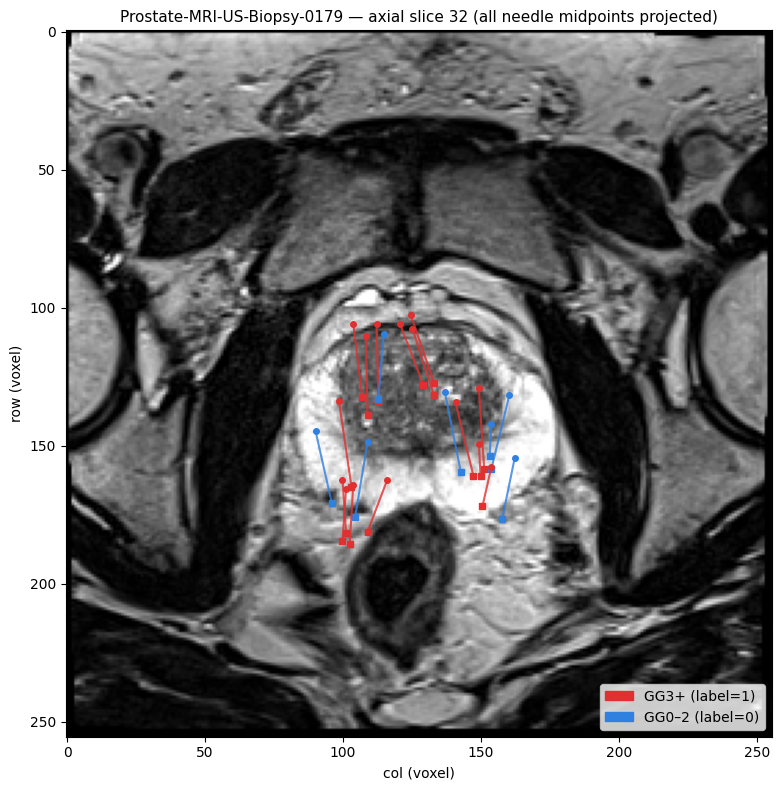

In [6]:
def window(img, low=5, high=99):
    """Percentile windowing for display."""
    lo, hi = np.percentile(img, low), np.percentile(img, high)
    return np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)

# Pick the slice closest to the mean midpoint of all needles
mean_slice = int(sub['mid_slice'].mean().round())
mean_slice = np.clip(mean_slice, 0, n_slices - 1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(window(volume[mean_slice]), cmap='gray', origin='upper')
ax.set_title(f'{SUBJECT} — axial slice {mean_slice} (all needle midpoints projected)', fontsize=11)

for _, row in sub.iterrows():
    color = '#e03030' if row.label == 1 else '#3080e0'
    # Project tip and base onto this axial plane (col, row axes)
    ax.plot([row.tip_col,  row.base_col],
            [row.tip_row,  row.base_row],
            color=color, linewidth=1.5, alpha=0.8)
    ax.plot(row.tip_col,  row.tip_row,  'o', color=color, markersize=4)
    ax.plot(row.base_col, row.base_row, 's', color=color, markersize=4)

legend = [
    mpatches.Patch(color='#e03030', label='GG3+ (label=1)'),
    mpatches.Patch(color='#3080e0', label='GG0–2 (label=0)'),
]
ax.legend(handles=legend, loc='lower right')
ax.set_xlabel('col (voxel)'); ax.set_ylabel('row (voxel)')
plt.tight_layout()
plt.show()

## 6. Visualisation — Needle-by-needle: axial slices along one needle

Pick a specific GG4 needle and visualise 5 evenly-spaced axial slices along it, with the needle cross-section marked.

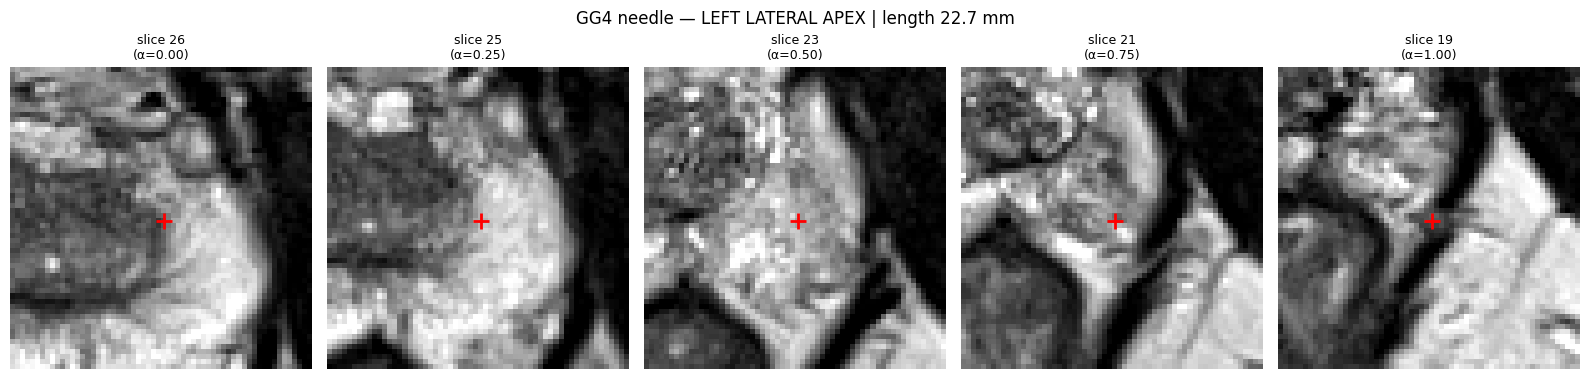

In [7]:
# Pick the first GG4 core
example = sub[sub['gleason_grade'] == 'GG4'].iloc[0]

tip_v  = np.array([example.tip_col,  example.tip_row,  example.tip_slice])
base_v = np.array([example.base_col, example.base_row, example.base_slice])

n_steps = 5
alphas  = np.linspace(0, 1, n_steps)
sample_pts = np.outer(1 - alphas, tip_v) + np.outer(alphas, base_v)  # (n_steps, 3)

fig, axes = plt.subplots(1, n_steps, figsize=(16, 4))
fig.suptitle(f"GG4 needle — {example.core_label} | "
             f"length {example.needle_length_mm:.1f} mm", fontsize=12)

MARGIN = 30  # display margin around the needle cross-section (voxels)

for ax, pt, a in zip(axes, sample_pts, alphas):
    k = int(np.clip(pt[2], 0, n_slices - 1))
    r = int(np.clip(pt[1], 0, n_rows   - 1))
    c = int(np.clip(pt[0], 0, n_cols   - 1))

    r0, r1 = max(0, r - MARGIN), min(n_rows,   r + MARGIN)
    c0, c1 = max(0, c - MARGIN), min(n_cols,   c + MARGIN)

    ax.imshow(window(volume[k, r0:r1, c0:c1]), cmap='gray', origin='upper')
    ax.plot(c - c0, r - r0, '+', color='red', markersize=12, markeredgewidth=2)
    ax.set_title(f"slice {k}\n(α={a:.2f})", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Visualisation — Coronal & Sagittal: needle as a full 3D line

We re-project the needle tip→base in the coronal (col–slice) and sagittal (row–slice) planes.

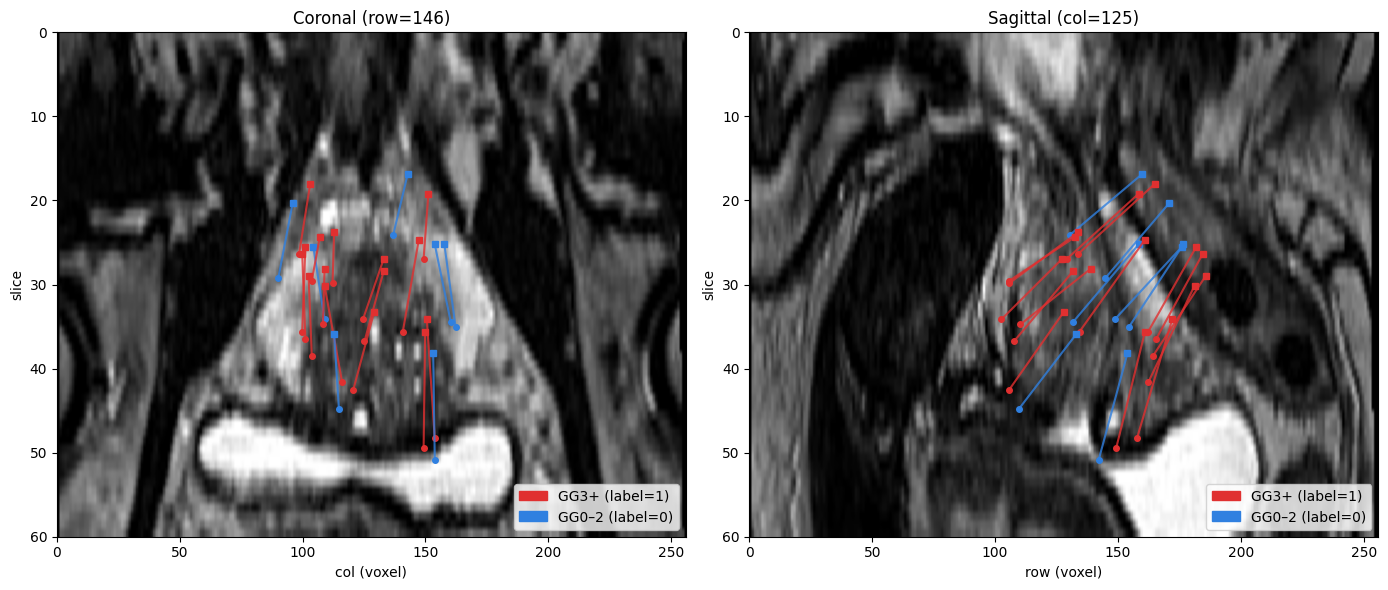

In [8]:
# Use mean row/col of all needles to pick the reference slice for each projection
mean_row = int(sub['mid_row'].mean().round())
mean_col = int(sub['mid_col'].mean().round())
mean_row = np.clip(mean_row, 0, n_rows - 1)
mean_col = np.clip(mean_col, 0, n_cols - 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Coronal: axes = (slice, col), fixed row ---
ax = axes[0]
coronal = volume[:, mean_row, :]  # (n_slices, n_cols)
ax.imshow(window(coronal), cmap='gray', origin='upper',
          aspect='auto', extent=[0, n_cols, n_slices, 0])
ax.set_title(f'Coronal (row={mean_row})')
ax.set_xlabel('col (voxel)'); ax.set_ylabel('slice')

for _, row in sub.iterrows():
    color = '#e03030' if row.label == 1 else '#3080e0'
    ax.plot([row.tip_col,  row.base_col],
            [row.tip_slice, row.base_slice],
            color=color, linewidth=1.5, alpha=0.8)
    ax.plot(row.tip_col,  row.tip_slice,  'o', color=color, markersize=4)
    ax.plot(row.base_col, row.base_slice, 's', color=color, markersize=4)

# --- Sagittal: axes = (slice, row), fixed col ---
ax = axes[1]
sagittal = volume[:, :, mean_col]  # (n_slices, n_rows)
ax.imshow(window(sagittal), cmap='gray', origin='upper',
          aspect='auto', extent=[0, n_rows, n_slices, 0])
ax.set_title(f'Sagittal (col={mean_col})')
ax.set_xlabel('row (voxel)'); ax.set_ylabel('slice')

for _, row in sub.iterrows():
    color = '#e03030' if row.label == 1 else '#3080e0'
    ax.plot([row.tip_row,  row.base_row],
            [row.tip_slice, row.base_slice],
            color=color, linewidth=1.5, alpha=0.8)
    ax.plot(row.tip_row,  row.tip_slice,  'o', color=color, markersize=4)
    ax.plot(row.base_row, row.base_slice, 's', color=color, markersize=4)

legend = [
    mpatches.Patch(color='#e03030', label='GG3+ (label=1)'),
    mpatches.Patch(color='#3080e0', label='GG0–2 (label=0)'),
]
for ax in axes:
    ax.legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.show()

## 8. Voxel size & resolution summary

Key numbers needed for Step 3 (ROI extraction).

In [9]:
vox_col   = np.linalg.norm(affine[:3, 0])  # mm / voxel along col axis
vox_row   = np.linalg.norm(affine[:3, 1])  # mm / voxel along row axis
vox_slice = np.linalg.norm(affine[:3, 2])  # mm / voxel along slice axis

print("=== Voxel size ===")
print(f"  col   : {vox_col:.3f} mm")
print(f"  row   : {vox_row:.3f} mm")
print(f"  slice : {vox_slice:.3f} mm")
print()

med_len = sub['needle_length_mm'].median()
print(f"Median needle length : {med_len:.1f} mm")
print(f"  → {med_len / vox_slice:.1f} voxels along needle axis (at {vox_slice:.2f} mm/voxel)")
print()

# Typical biopsy needle gauge 18G → ~1.2 mm diameter
needle_radius_mm = 1.5  # add margin
print(f"Needle radius (+ margin): {needle_radius_mm} mm")
print(f"  → {needle_radius_mm / vox_col:.1f} voxels radially  (at {vox_col:.2f} mm/voxel)")

=== Voxel size ===
  col   : 0.664 mm
  row   : 0.664 mm
  slice : 1.500 mm

Median needle length : 21.2 mm
  → 14.1 voxels along needle axis (at 1.50 mm/voxel)

Needle radius (+ margin): 1.5 mm
  → 2.3 voxels radially  (at 0.66 mm/voxel)


## Summary

- The DICOM affine is **verified**: origin maps to (0,0,0), round-trip error < 1e-10 voxels  
- `lps_to_voxel` and `voxel_to_lps` are ready to promote to `src/dicom_utils.py` for Step 3  
- Needles are **visually aligned** with the prostate anatomy on all three views  
- The voxel geometry confirms: needles are ~13–14 voxels long axially, ~1–2 voxels radius radially  
- **Next step:** extract the needle-aligned cylindrical ROI for each core (Step 3)

---

## 9. Contamination Analysis — Cylindrical ROI overlap at r = 2mm

**Motivation:** biopsy needles within the same session can be spatially close. If a label=0 needle's cylindrical ROI (r=2mm) overlaps with a label=1 needle's ROI, cancer tissue leaks into the negative sample — a source of label noise.

**Only 01/10 mixed pairs are a problem.** 00 and 11 pairs share the same label, so overlap between them is harmless.

**Method:**
- For every pair of needles in the same session, approximate the volumetric overlap using the **cross-sectional lens formula** integrated along each needle's axis.
- Overlap = `max(fraction of A inside B, fraction of B inside A)`.
- For any 01/10 pair with overlap > 1%, drop the **label=0 core** (we have surplus negatives; we cannot afford to lose GG3+ samples).

**Scatter plot:** overlap % (x) vs label pair type (y, jittered) to visualise the contamination landscape.

In [10]:
from itertools import combinations

RADIUS_MM = 2.0
N_AXIS_SAMPLES = 40   # points sampled along each needle axis for the lens integral


def point_to_segment_dist(p: np.ndarray, a: np.ndarray, b: np.ndarray) -> float:
    """Minimum distance from point p to line segment a→b."""
    ab = b - a
    len2 = np.dot(ab, ab)
    if len2 < 1e-12:
        return float(np.linalg.norm(p - a))
    t = np.clip(np.dot(p - a, ab) / len2, 0.0, 1.0)
    return float(np.linalg.norm(p - (a + t * ab)))


def segment_min_dist(a1: np.ndarray, b1: np.ndarray,
                     a2: np.ndarray, b2: np.ndarray,
                     n: int = 20) -> float:
    """Approximate minimum distance between two line segments (fast screening)."""
    best = np.inf
    for t in np.linspace(0, 1, n):
        best = min(best, point_to_segment_dist(a1 + t*(b1-a1), a2, b2))
        best = min(best, point_to_segment_dist(a2 + t*(b2-a2), a1, b1))
    return best


def lens_fraction(d: float, r: float) -> float:
    """
    Fraction of a circle of radius r that overlaps with another circle of
    radius r whose centre is at distance d away.
    """
    if d >= 2 * r:
        return 0.0
    if d <= 0.0:
        return 1.0
    cos_arg = np.clip(d / (2 * r), -1.0, 1.0)
    area_intersection = 2 * r**2 * np.arccos(cos_arg) - (d / 2) * np.sqrt(4*r**2 - d**2)
    return float(area_intersection / (np.pi * r**2))


def cylinder_overlap(tip_a: np.ndarray, base_a: np.ndarray,
                     tip_b: np.ndarray, base_b: np.ndarray,
                     r: float = RADIUS_MM,
                     n: int = N_AXIS_SAMPLES) -> tuple[float, float]:
    """
    Fraction of cylinder A's volume that lies inside cylinder B, and vice versa.
    Estimated by integrating the cross-sectional lens area along each axis.
    Returns (frac_A_in_B, frac_B_in_A).
    """
    # Fraction of A inside B
    ts = np.linspace(0, 1, n)
    pts_a = np.outer(1 - ts, tip_a) + np.outer(ts, base_a)
    dists_a = np.array([point_to_segment_dist(p, tip_b, base_b) for p in pts_a])
    frac_a_in_b = float(np.mean([lens_fraction(d, r) for d in dists_a]))

    # Fraction of B inside A
    pts_b = np.outer(1 - ts, tip_b) + np.outer(ts, base_b)
    dists_b = np.array([point_to_segment_dist(p, tip_a, base_a) for p in pts_b])
    frac_b_in_a = float(np.mean([lens_fraction(d, r) for d in dists_b]))

    return frac_a_in_b, frac_b_in_a


print(f"Overlap functions defined. r = {RADIUS_MM} mm, {N_AXIS_SAMPLES} axis samples per needle.")
print()

# Quick unit test
print("Lens fraction tests:")
print(f"  d=0   (full overlap): {lens_fraction(0,   RADIUS_MM):.3f}  (expected 1.000)")
print(f"  d=2r  (touching):     {lens_fraction(4.0, RADIUS_MM):.3f}  (expected 0.000)")
print(f"  d=r   (half apart):   {lens_fraction(2.0, RADIUS_MM):.3f}  (expected ~0.391)")

Overlap functions defined. r = 2.0 mm, 40 axis samples per needle.

Lens fraction tests:
  d=0   (full overlap): 1.000  (expected 1.000)
  d=2r  (touching):     0.000  (expected 0.000)
  d=r   (half apart):   0.391  (expected ~0.391)


In [11]:
from tqdm.auto import tqdm as tqdm_auto

# Run over ALL sessions in the manifest
# Screen: only compute full overlap if min_dist < 2 * RADIUS_MM (= 4mm)
SCREEN_DIST = 2 * RADIUS_MM

tips_all  = manifest[['tip_x_mri',  'tip_y_mri',  'tip_z_mri']].values
bases_all = manifest[['base_x_mri', 'base_y_mri', 'base_z_mri']].values
labels_all = manifest['label'].values
ids_all    = manifest['core_id'].values

sessions = manifest.groupby(['subject_id', 'series_uid_mri'])

records = []
skipped_screen = 0

for key, grp in tqdm_auto(sessions, desc='Sessions', total=sessions.ngroups):
    idxs = grp.index.tolist()
    if len(idxs) < 2:
        continue
    for ii, jj in combinations(idxs, 2):
        tip_a,  base_a  = tips_all[ii],  bases_all[ii]
        tip_b,  base_b  = tips_all[jj],  bases_all[jj]
        label_a, label_b = labels_all[ii], labels_all[jj]

        # Fast screen
        if segment_min_dist(tip_a, base_a, tip_b, base_b) >= SCREEN_DIST:
            skipped_screen += 1
            continue

        frac_a, frac_b = cylinder_overlap(tip_a, base_a, tip_b, base_b)
        max_overlap = max(frac_a, frac_b)

        pair_type = f"{int(label_a)}{int(label_b)}" if label_a <= label_b else f"{int(label_b)}{int(label_a)}"

        records.append({
            'core_id_a':    ids_all[ii],
            'core_id_b':    ids_all[jj],
            'label_a':      label_a,
            'label_b':      label_b,
            'pair_type':    pair_type,   # '00', '01', '11'
            'frac_a_in_b':  frac_a,
            'frac_b_in_a':  frac_b,
            'max_overlap':  max_overlap,
        })

pairs_df = pd.DataFrame(records)
print(f"Sessions scanned   : {sessions.ngroups}")
print(f"Pairs screened out : {skipped_screen:,}  (min_dist ≥ {SCREEN_DIST}mm → no overlap possible)")
print(f"Pairs with overlap : {len(pairs_df):,}")
print()
print("Breakdown by label pair type:")
print(pairs_df.groupby('pair_type')['max_overlap'].describe().round(3).to_string())

Sessions:   0%|          | 0/963 [00:00<?, ?it/s]

Sessions scanned   : 963
Pairs screened out : 154,866  (min_dist ≥ 4.0mm → no overlap possible)
Pairs with overlap : 14,451

Breakdown by label pair type:
             count   mean    std  min    25%    50%    75%    max
pair_type                                                        
00         13666.0  0.141  0.166  0.0  0.014  0.071  0.221  0.916
01           568.0  0.127  0.162  0.0  0.009  0.053  0.200  0.747
11           217.0  0.150  0.183  0.0  0.011  0.069  0.232  0.783


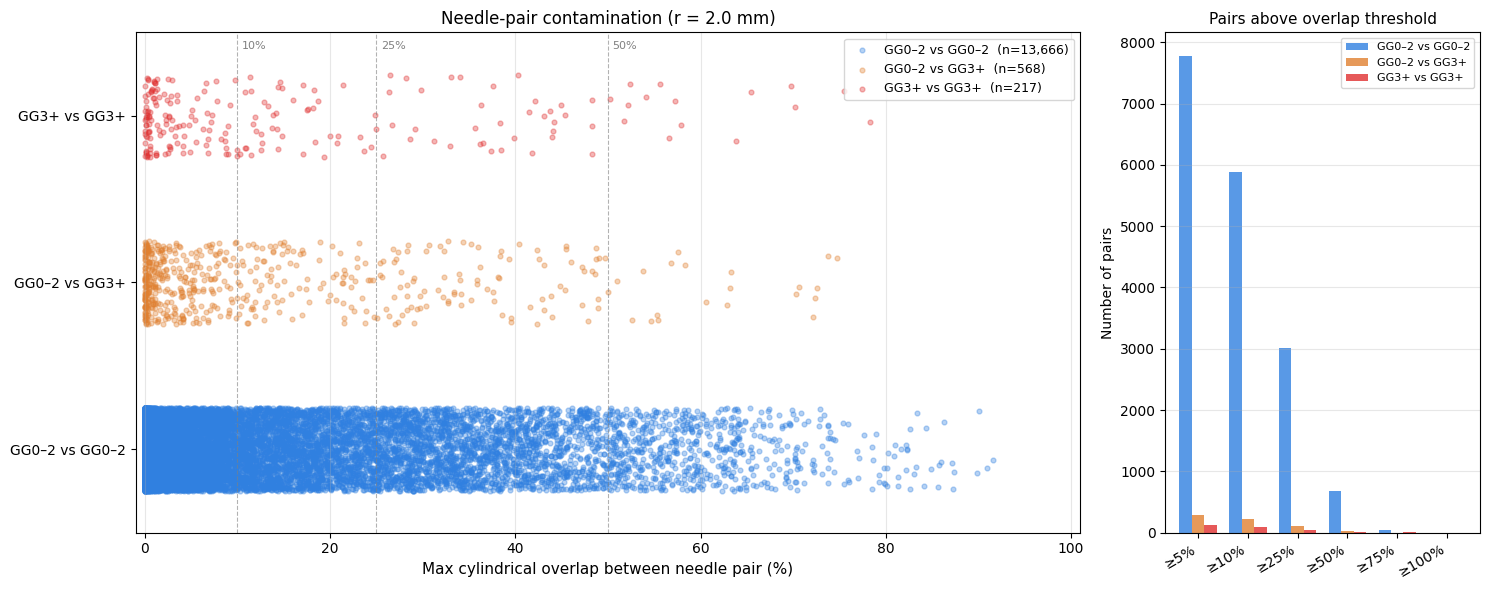

In [12]:
np.random.seed(0)

PAIR_ORDER  = ['00', '01', '11']
PAIR_LABELS = {'00': 'GG0–2 vs GG0–2', '01': 'GG0–2 vs GG3+', '11': 'GG3+ vs GG3+'}
PAIR_COLORS = {'00': '#3080e0', '01': '#e08030', '11': '#e03030'}
JITTER_Y    = {'00': 0.0,       '01': 1.0,       '11': 2.0}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [3, 1]})

# ── Left: scatter plot ──────────────────────────────────────────────────────
ax = axes[0]
for pt in PAIR_ORDER:
    sub_p = pairs_df[pairs_df['pair_type'] == pt]
    y_base = JITTER_Y[pt]
    jitter = np.random.uniform(-0.25, 0.25, len(sub_p))
    ax.scatter(
        sub_p['max_overlap'] * 100,
        y_base + jitter,
        c=PAIR_COLORS[pt],
        alpha=0.35,
        s=12,
        label=f"{PAIR_LABELS[pt]}  (n={len(sub_p):,})",
        rasterized=True,
    )

# Threshold lines
for thresh in [10, 25, 50]:
    ax.axvline(thresh, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(thresh + 0.5, 2.4, f'{thresh}%', fontsize=8, color='gray')

ax.set_yticks([0, 1, 2])
ax.set_yticklabels([PAIR_LABELS[p] for p in PAIR_ORDER])
ax.set_xlabel('Max cylindrical overlap between needle pair (%)', fontsize=11)
ax.set_title(f'Needle-pair contamination (r = {RADIUS_MM} mm)', fontsize=12)
ax.set_xlim(-1, 101)
ax.set_ylim(-0.5, 2.5)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='x', alpha=0.3)

# ── Right: count histogram per threshold per pair type ─────────────────────
ax2 = axes[1]
thresholds = [5, 10, 25, 50, 75, 100]
bar_width  = 0.25
x = np.arange(len(thresholds))
for k, pt in enumerate(PAIR_ORDER):
    sub_p  = pairs_df[pairs_df['pair_type'] == pt]
    counts = [( sub_p['max_overlap'] * 100 >= t).sum() for t in thresholds]
    ax2.bar(x + k * bar_width, counts, bar_width,
            label=PAIR_LABELS[pt], color=PAIR_COLORS[pt], alpha=0.8)

ax2.set_xticks(x + bar_width)
ax2.set_xticklabels([f'≥{t}%' for t in thresholds], rotation=30, ha='right')
ax2.set_ylabel('Number of pairs')
ax2.set_title('Pairs above overlap threshold', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/contamination_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Removal strategy ────────────────────────────────────────────────────────
# Only 01/10 pairs are problematic: a GG0-2 ROI overlapping with a GG3+ ROI
# has cancer signal leaking into a negative sample → drop the label=0 core.
#
# 00 and 11 pairs: same label on both sides → overlap is irrelevant, keep both.
#
# Threshold: any non-negligible overlap (> 1%) triggers removal.
# We set a small floor to ignore numerical noise from nearly-touching needles.

MIN_OVERLAP = 0.01  # 1% — effectively "any real overlap"

pairs_01 = pairs_df[
    (pairs_df['pair_type'] == '01') &
    (pairs_df['max_overlap'] > MIN_OVERLAP)
].copy()

# For each 01 pair, identify which core_id is label=0
def get_label0_core(row):
    if row['label_a'] == 0:
        return row['core_id_a']
    return row['core_id_b']

to_drop = set(pairs_01.apply(get_label0_core, axis=1))

print(f"=== Removal strategy: drop label=0 from every 01/10 overlapping pair ===")
print(f"  Min overlap threshold : {MIN_OVERLAP*100:.0f}%")
print(f"  Overlapping 01 pairs  : {len(pairs_01):,}")
print(f"  Unique label=0 cores to drop: {len(to_drop):,}")
print()

kept = manifest[~manifest['core_id'].isin(to_drop)]
print("Class distribution after removal:")
print(kept['gleason_grade'].value_counts().to_string())
print()
print(f"  label=0 : {(kept['label']==0).sum():,}  →  was {(manifest['label']==0).sum():,}  (−{len(to_drop):,})")
print(f"  label=1 : {(kept['label']==1).sum():,}  →  unchanged")
print()

# Sanity: confirm no GG3+ cores were dropped
dropped_manifest = manifest[manifest['core_id'].isin(to_drop)]
assert (dropped_manifest['label'] == 0).all(), "ERROR: a label=1 core was flagged!"
print("Sanity check passed: all dropped cores are label=0.")
print()
print("Saved → data/cores_to_drop_contamination.csv")
pd.DataFrame({'core_id': sorted(to_drop)}).to_csv('../data/cores_to_drop_contamination.csv', index=False)

=== Removal strategy: drop label=0 from every 01/10 overlapping pair ===
  Min overlap threshold : 1%
  Overlapping 01 pairs  : 421
  Unique label=0 cores to drop: 343

Class distribution after removal:
gleason_grade
Benign    12836
GG1        2074
GG2        1133
GG3         329
GG4         186
GG5         132

  label=0 : 16,043  →  was 16,386  (−343)
  label=1 : 647  →  unchanged

Sanity check passed: all dropped cores are label=0.

Saved → data/cores_to_drop_contamination.csv
